<a href="https://colab.research.google.com/github/Mahaboob-Ashraf/IIITH-internship-log/blob/main/Eagle_Eye_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

!pip install ultralytics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.7 MB/s eta 0:00:00


In [2]:
!unzip /content/drive/MyDrive/dataset.zip -d /content/

Archive:  /content/drive/MyDrive/dataset.zip
   creating: /content/dataset/
   creating: /content/dataset/train/
   creating: /content/dataset/train/images/
  inflating: /content/dataset/train/images/0003.jpg  
  inflating: /content/dataset/train/images/0004.jpg  
  inflating: /content/dataset/train/images/0005.jpg  
  inflating: /content/dataset/train/images/0006.jpg  
  inflating: /content/dataset/train/images/0008.jpg  
  inflating: /content/dataset/train/images/0009.jpg  
  inflating: /content/dataset/train/images/0010.jpg  
  inflating: /content/dataset/train/images/0013.jpg  
  inflating: /content/dataset/train/images/0014.jpg  
  inflating: /content/dataset/train/images/0015.jpg  
  inflating: /content/dataset/train/images/0016.jpg  
  inflating: /content/dataset/train/images/0022.jpg  
  inflating: /content/dataset/train/images/0024.jpg  
  inflating: /content/dataset/train/images/0026.jpg  
  inflating: /content/dataset/train/images/0028.jpg  
  inflating: /content/dataset/tra

In [3]:
import yaml

data = {
    'path': '/content/dataset',
    'train': 'train/images',
    'val': 'valid/images',
    'names': {0: 'drone'}
}

with open('/content/uav_data.yaml', 'w') as f:
    yaml.dump(data, f)

In [4]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')
model.train(data='/content/uav_data.yaml', epochs=50, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/uav_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfcf0995c40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
from ultralytics import YOLO


model = YOLO('/content/runs/detect/train/weights/best.pt')

# Run detailed validation
metrics = model.val(
    data='uav_data.yaml',   # Point to your UAV dataset config
    split='val',        # Use the validation split
    save_json=True,     # Save raw data
    conf=0.25,          # Confidence threshold
    plots=True
)

print(f"Mean Average Precision (mAP50): {metrics.box.map50}")

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2341.2±1304.3 MB/s, size: 280.6 KB)
val: Scanning /content/dataset/valid/labels.cache... 272 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 272/272 534.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.2it/s 7.7s
                   all        272        287      0.947      0.932      0.967      0.732
Speed: 2.4ms preprocess, 16.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Saving /content/runs/detect/val2/predictions.json...
Results saved to /content/runs/detect/val2
Mean Average Precision (mAP50): 0.966689588022589


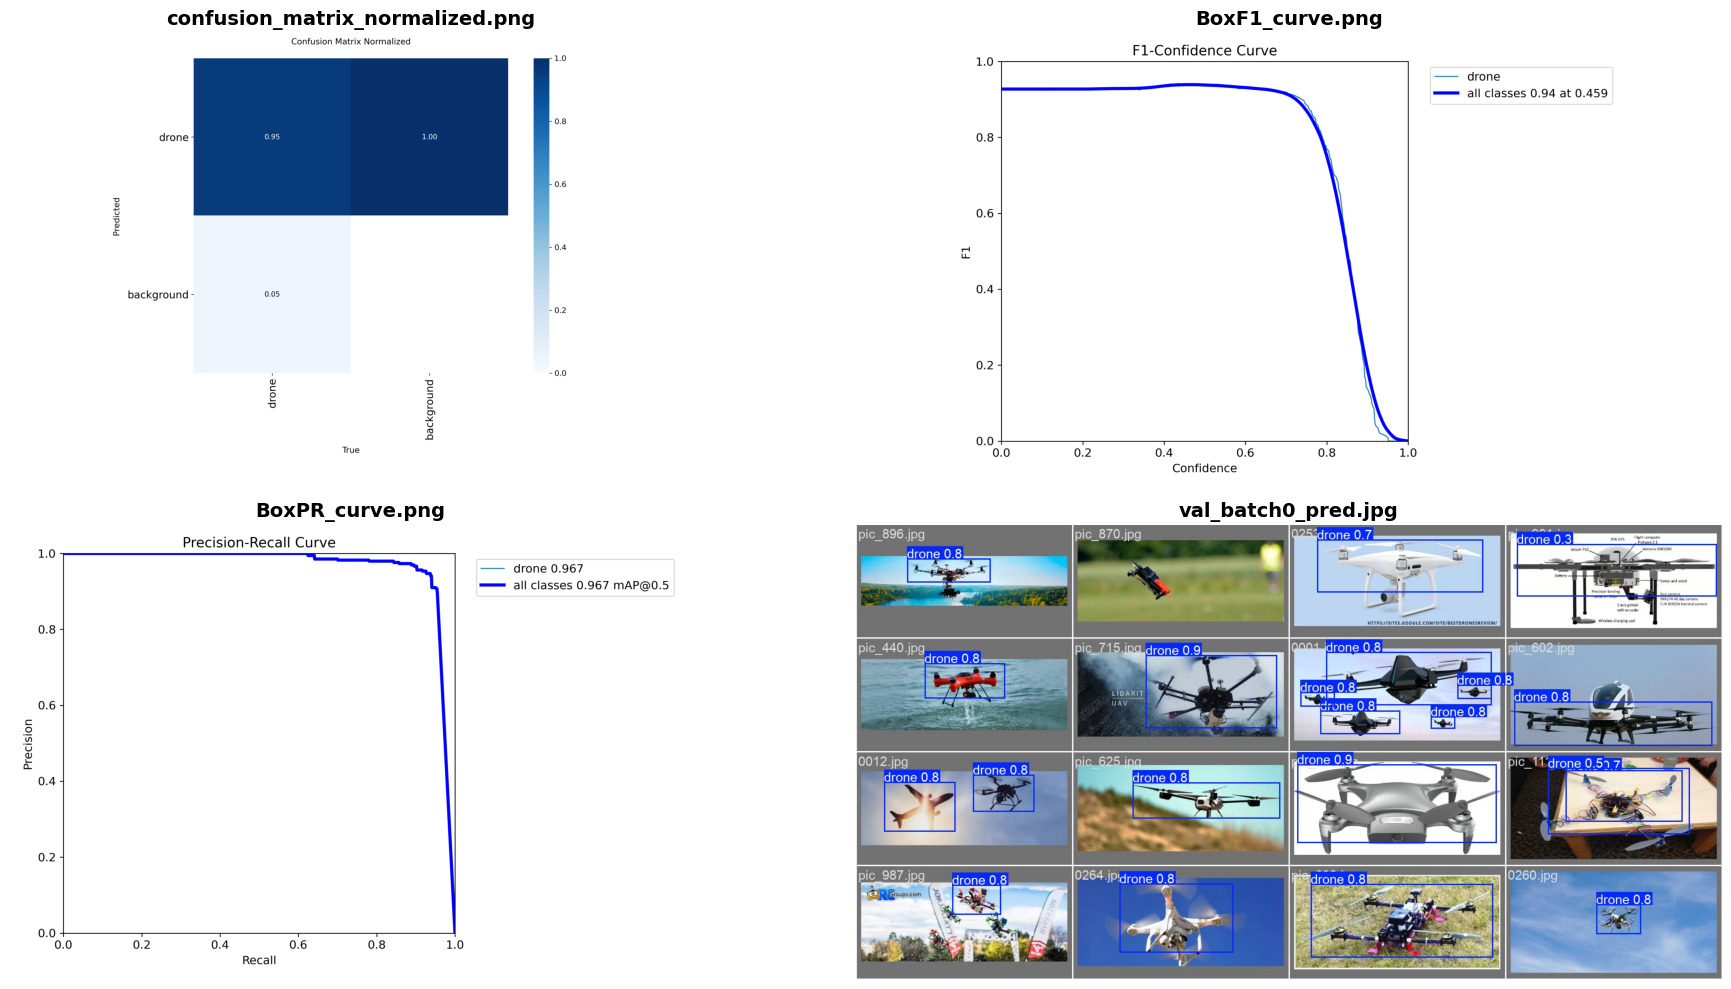

In [8]:
import matplotlib.pyplot as plt
import cv2
import os


val_path = '/content/runs/detect/val2'


graphs_to_show = [
    'confusion_matrix_normalized.png',  # Accuracy matrix
    'BoxF1_curve.png',                  # F1 Confidence Curve
    'BoxPR_curve.png',                  # Precision-Recall Curve
    'val_batch0_pred.jpg'               # Actual prediction
]

plt.figure(figsize=(20, 10))

for i, graph_name in enumerate(graphs_to_show):
    path = os.path.join(val_path, graph_name)
    if os.path.exists(path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(graph_name, fontsize=14, fontweight='bold')
    else:
        print(f"Warning: {graph_name} not found in {val_path}")

plt.tight_layout()
plt.show()